# Live (online) follicular→luteal transition detection

The other analysis notebooks solve a **retrospective** problem: `01_discovery.ipynb`,
`02_model_hsmm.ipynb`, and `03_validate_mcphases.ipynb` all use the *whole* cycle — including
`cycle_len`, which you only know once the **next** period starts. They *smooth*; they cannot run
in real time.

This notebook asks the **filtering** question instead: *standing on day t of an in-progress cycle,
with data only up to today, has the follicular→luteal transition happened yet?* This is a causal
change-point / detection problem, and it is single-participant by nature — we track **one person's**
cycles and learn **their** biometric shift from **their** past cycles as data arrives.

**Design (three rules that keep it honest / leak-free):**

1. **Personal & expanding-window.** Detector parameters for cycle *k* are trained only on that
   person's **completed** cycles `1..k-1`. The first few cycles are a warm-up (not scored).
2. **Causal normalisation.** Period onset is always known live, so each signal is normalised to the
   **current cycle's early-follicular baseline** (first few post-period days) — available *before*
   the transition — scaled by a robust spread estimated from **prior** cycles only.
3. **Streaming decision.** A per-day luteal probability feeds a **CUSUM / SPRT** accumulator; the
   transition is *declared* the first day the accumulated evidence crosses a threshold. The day it
   fires, minus the true transition day, is the **detection delay** — the price of being causal.

We measure delay against two references: **Garmin's ovulation** (fertile-window end − 2, the
physiological event) and a **full-information biometric boundary** (what the retrospective HSMM-style
segmenter sees). Delay-vs-Garmin includes the biometric lag; delay-vs-full-info isolates the pure
detection lag.


In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "analysis").exists():
    REPO_ROOT = Path("/home/elsa/projects/garmin")
sys.path.insert(0, str(REPO_ROOT / "analysis"))   # make the `cyclelib` package importable

# Emission log-density shared with 02_model_hsmm / 03_validate_mcphases. The forward
# filter below is genuinely online (an alpha-recursion), but its per-day Gaussian
# scoring is the same math, so it reuses the library's logmvn.
from cyclelib.hsmm import logmvn as _logmvn

CSV = REPO_ROOT / "data/garmin_data_730days/garmin_data_730days_preprocessed.csv"
SIG = ["resting_hr", "hrv_rmssd", "avg_sleep_respiration", "avg_sleep_stress"]

d = pd.read_csv(CSV, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
for s in SIG:
    d[s] = d[s].ffill()         # forward-fill only = no peeking at future days

# --- cycle structure (a cycle starts on the first day of a Period run) ---
ip = d["is_period"].fillna(False).astype(bool).to_numpy()
d["is_period"] = ip
d["cycle_id"] = (ip & ~np.r_[False, ip[:-1]]).cumsum()
first = d.groupby("cycle_id")["date"].min()
d["cycle_day"] = (d["date"] - d["cycle_id"].map(first)).dt.days
d["cycle_len"] = d["cycle_id"].map((first.shift(-1) - first).dt.days)
pe = d[d["is_period"]].groupby("cycle_id")["cycle_day"].max() + 1
d["period_end"] = d["cycle_id"].map(pe)

# --- reference event A: Garmin fertile-window ovulation (fertile end - 2 days) ---
fert = d[d["garmin_predicted_fertile"].fillna(False).astype(bool)]
d["ov_ref"] = d["cycle_id"].map(fert.groupby("cycle_id")["cycle_day"].max() - 2)

CYCLES = [c for c in sorted(d["cycle_id"].unique())
          if c > 0 and pd.notna(d.loc[d["cycle_id"] == c, "cycle_len"].iloc[0])]
print(f"complete cycles: {len(CYCLES)} | "
      f"median length {d.groupby('cycle_id')['cycle_len'].first().median():.0f} d | "
      f"cycles with Garmin ovulation ref: {d.groupby('cycle_id')['ov_ref'].first().notna().sum()}")


## Causal features & the anti-leakage contract

The single most important difference from the retrospective notebooks is that **nothing after the
current day may touch the day-t decision.** Concretely:

- `causal_z(cycle)` subtracts the **current cycle's** mean over `[period_end, period_end + K_BASE)`
  (the early-follicular nadir, known by the time the transition could occur) and divides by a robust
  **prior-cycles** scale. The detector only starts accumulating at `cycle_day ≥ period_end + K_BASE`,
  so the baseline window is fully in the past when any decision is made.
- `anchors(prior_cycles)` builds the training set from **completed** cycles only: follicular =
  post-menstrual window, luteal = last 6 days before that (already finished) cycle's next period.
- `MIN_TRAIN` completed cycles are required before a cycle is scored at all (warm-up).


In [2]:
K_BASE = 4        # early-follicular baseline width (days after period_end)
MIN_TRAIN = 3     # warm-up: completed cycles required before scoring


def cycle(c):
    return d[d["cycle_id"] == c].sort_values("cycle_day")


def robust_scale(prior_ids):
    """Per-signal robust spread (MAD*1.4826) from PRIOR cycles only."""
    f = d[d["cycle_id"].isin(prior_ids)]
    return {s: max(1e-6, (f[s] - f[s].median()).abs().median() * 1.4826) for s in SIG}


def causal_z(g, scale):
    """Signals normalised to THIS cycle's early-follicular baseline / prior-cycle scale."""
    p0 = int(g["period_end"].iloc[0])
    base = g[(g["cycle_day"] >= p0) & (g["cycle_day"] < p0 + K_BASE)][SIG].mean()
    return (g[SIG] - base) / pd.Series(scale)


def anchors(prior_ids, scale):
    """Follicular (post-menstrual) vs luteal (last 6 d) rows from completed prior cycles."""
    F, L = [], []
    for c in prior_ids:
        g = cycle(c)
        cl = int(g["cycle_len"].iloc[0])
        p0 = int(g["period_end"].iloc[0])
        z = causal_z(g, scale)
        cd = g["cycle_day"].to_numpy()
        ipp = g["is_period"].to_numpy()
        F.append(z[(~ipp) & (cd >= p0) & (cd < min(p0 + 6, cl - 16))])
        L.append(z[(~ipp) & (cd >= cl - 6) & (cd < cl)])
    F = pd.concat(F).dropna()
    L = pd.concat(L).dropna()
    X = np.vstack([F.to_numpy(), L.to_numpy()])
    y = np.r_[np.zeros(len(F)), np.ones(len(L))]
    return X, y


## Reference transitions (to measure delay against)

To score a live detection we need to know when the transition *actually* was. Two references:

- **A — Garmin ovulation** (`ov_ref`, above): the hormonal-ish event. A biometric detector fires a
  few days *after* this (progesterone/RHR lag + detection lag), so a small positive delay is expected.
- **B — full-information biometric boundary**: the same single-boundary MAP the retrospective
  notebooks use, run with the *whole* cycle visible (pooled Gaussian emissions over all of this
  person's cycles + the luteal-duration prior). This is the best a **smoothing** model can do;
  delay-vs-B isolates the cost of being **causal** rather than the biometric lag.


In [ ]:
DUR_MU, DUR_SD = 13.0, 2.5      # luteal-duration prior (validated on mcPHASES)

# Retrospective per-person standardisation (whole record -> allowed for a smoothing reference).
zr = {s: (d[s] - d[s].median()) / max(1e-6, (d[s] - d[s].median()).abs().median() * 1.4826)
      for s in SIG}
Zr = np.column_stack([zr[s] for s in SIG])
d_zr = pd.DataFrame(Zr, columns=SIG, index=d.index)


def _mvn(rows, reg=0.2):
    return rows.mean(0), np.cov(rows.T) + reg * np.eye(len(SIG))

# _logmvn is imported from cyclelib.hsmm (same emission log-density as the other notebooks).


def retro_boundaries():
    """Full-information first-luteal-day per cycle (pooled Gaussian + duration prior)."""
    F, L = [], []
    for c in CYCLES:
        g = cycle(c)
        cl = int(g["cycle_len"].iloc[0])
        p0 = int(g["period_end"].iloc[0])
        Z = d_zr.loc[g.index].to_numpy()
        cd = g["cycle_day"].to_numpy()
        ipp = g["is_period"].to_numpy()
        F.append(Z[(~ipp) & (cd >= p0) & (cd < min(p0 + 6, cl - 16))])
        L.append(Z[(~ipp) & (cd >= cl - 6) & (cd < cl)])
    muF, SF = _mvn(np.vstack(F))
    muL, SL = _mvn(np.vstack(L))
    out = {}
    for c in CYCLES:
        g = cycle(c)
        cl = int(g["cycle_len"].iloc[0])
        p0 = int(g["period_end"].iloc[0])
        Z = d_zr.loc[g.index].to_numpy()
        cd = g["cycle_day"].to_numpy()
        ipp = g["is_period"].to_numpy()
        lF = _logmvn(Z, muF, SF)
        lL = _logmvn(Z, muL, SL)
        cands = np.arange(max(p0 + 4, cl - 19), cl - 3)
        if len(cands) == 0:
            continue
        sc = [lF[(~ipp) & (cd >= p0) & (cd < b)].sum() + lL[(~ipp) & (cd >= b)].sum()
              - 0.5 * ((cl - b - DUR_MU) / DUR_SD) ** 2 for b in cands]
        out[c] = int(cands[int(np.argmax(sc))])
    return out


RETRO = retro_boundaries()
print("full-info biometric boundary (cycle_day): median",
      int(np.median(list(RETRO.values()))),
      "| vs Garmin ovulation median offset",
      float(np.median([RETRO[c] - d.loc[d.cycle_id == c, "ov_ref"].iloc[0]
                       for c in RETRO if pd.notna(d.loc[d.cycle_id == c, "ov_ref"].iloc[0])])))


## The detector — personal `P(luteal)` + CUSUM, and its two knobs

Each day gets a luteal probability from a **logistic regression** trained on this person's prior
cycles. Those probabilities feed a **CUSUM** accumulator (a sequential probability-ratio test):

$$S_t = \max\big(0,\; S_{t-1} + \log\tfrac{p_t}{1-p_t} - K\big),\qquad \text{fire when } S_t > H.$$

There are **two** knobs, and they interact — so we grid-search **both**:

- **`K` (drift / dead-band).** Subtracted every day. A larger `K` holds `S` at zero through
  follicular noise and only lets a *sustained* luteal shift accumulate — fewer early trips, but a
  slower climb once the transition starts.
- **`H` (threshold).** How much evidence must pile up before we declare the transition.

Because the daily probabilities don't depend on `H` or `K`, we fit each cycle's trajectory **once**
and then scan the whole `(H, K)` grid in `O(days)`.

**Scoring both failure modes.** A one-sided "false-alarm rate" is gameable: a detector that fires on
cycle-day 11 — *before* the real transition — collects "detections" with a *negative* delay and
looks perfect (this is exactly what the raw-detection-rate optimum does). So we score with a
**two-sided cost** measured against the full-information biometric boundary: firing **early** (before
the shift) and firing **late** (detection lag) are *both* penalised, and never firing pays a flat
**miss** price. The three weights (`W_EARLY`, `W_LATE`, `C_MISS`) are explicit — set them to your
use-case's tolerance for a premature vs. a tardy vs. a missed call, and the grid returns the
operating point that minimises expected cost.


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

EPS = 1e-4


def fit_personal(prior_ids, scale):
    X, y = anchors(prior_ids, scale)
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X, y)


def cycle_probs(c):
    """Fit on PRIOR cycles, return this cycle's causal luteal-prob trajectory.

    The probabilities depend only on the (expanding-window) classifier, not on the CUSUM
    knobs -- so we compute them once per cycle and scan (H, K) cheaply afterwards.
    """
    i = CYCLES.index(c)
    prior = CYCLES[:i]
    if len(prior) < MIN_TRAIN:
        return None
    scale = robust_scale(prior)
    clf = fit_personal(prior, scale)
    g = cycle(c)
    cl = int(g["cycle_len"].iloc[0])
    p0 = int(g["period_end"].iloc[0])
    z = causal_z(g, scale).to_numpy()
    cd = g["cycle_day"].to_numpy()
    ipp = g["is_period"].to_numpy()
    p = clf.predict_proba(np.nan_to_num(z))[:, 1]
    ov = d.loc[d.cycle_id == c, "ov_ref"].iloc[0]
    return {"cyc": int(c), "cl": cl, "p0": p0, "cd": cd, "ipp": ipp, "p": p,
            "ov": None if pd.isna(ov) else int(ov), "retro": RETRO.get(c)}

# probabilities are (H, K)-independent: fit once per cycle, then thresholds scan in O(days)
PC = [r for r in (cycle_probs(c) for c in CYCLES) if r is not None]

def scan(rec, H, K):
    """Run the CUSUM over a precomputed trajectory. Returns (S-path, fire cycle_day or None).

    Accumulation starts only at period_end + K_BASE, so the early-follicular baseline window is
    fully in the past at any decision (strictly causal).
    """
    lg = (np.log(np.clip(rec["p"], EPS, 1 - EPS))
          - np.log(np.clip(1 - rec["p"], EPS, 1 - EPS)))
    S = 0.0; traj = np.zeros(len(rec["cd"])); fire = None
    for t in range(len(rec["cd"])):
        if (not rec["ipp"][t]) and rec["cd"][t] >= rec["p0"] + K_BASE:
            S = max(0.0, S + lg[t] - K)
            if S > H and fire is None:
                fire = int(rec["cd"][t])
        traj[t] = S
    return traj, fire


def run_stream(H, K):
    rows = []
    for r in PC:
        _, fire = scan(r, H, K)
        rows.append({"cyc": r["cyc"], "cl": r["cl"], "ov": r["ov"], "retro": r["retro"], "fire": fire,
                     "delay_ov": None if (fire is None or r["ov"] is None) else fire - r["ov"],
                     "delay_retro": None if (fire is None or r["retro"] is None) else fire - r["retro"]})
    return pd.DataFrame(rows)


print(f"precomputed luteal-prob trajectories for {len(PC)} evaluated cycles "
      f"(classifier fit once each; (H,K) now scans in O(days))")


precomputed luteal-prob trajectories for 23 evaluated cycles (classifier fit once each; (H,K) now scans in O(days))


In [7]:
# --- two-sided cost: penalise firing EARLY, firing LATE, and never firing ---
# Reference "transition" = the full-information biometric boundary (RETRO) -- the best a smoothing
# model can localise, so it is the fair target for a causal detector. delay = fire - retro:
#   delay < 0  fired BEFORE the biometric shift (jumped on noise -> the gameable "early detection")
#   delay > 0  fired AFTER  the shift (genuine detection lag, the price of being causal)
#   fire is None -> never fired (a miss).
W_EARLY = 1.5     # cost per day of firing before the transition (asymmetric: early is worse)
W_LATE  = 1.0     # cost per day of detection lag after the transition
C_MISS  = 12.0    # flat penalty (days-equivalent) for never firing


def cycle_cost(fire, ref):
    if fire is None:
        return C_MISS
    if ref is None:
        return np.nan                      # no reference -> excluded from the mean
    dl = fire - ref
    return W_LATE * dl if dl >= 0 else W_EARLY * (-dl)


def mean_cost(H, K):
    return np.nanmean([cycle_cost(scan(r, H, K)[1], r["retro"]) for r in PC])


# joint grid over BOTH knobs (drift K and threshold H)
Hs = np.round(np.arange(0.0, 3.01 , 0.05), 3)
Ks = np.round(np.arange(0.0, 1.51, 0.05), 3)
COST = np.array([[mean_cost(H, K) for H in Hs] for K in Ks])     # rows = K, cols = H

ki, hi = np.unravel_index(np.nanargmin(COST), COST.shape)
H0, K0 = float(Hs[hi]), float(Ks[ki])
print(f"cost-optimal operating point:  H={H0}  K={K0}  mean cost = {COST[ki, hi]:.2f} days")


def operating_point_summary(H, K):
    """One-row summary for a candidate live-detector operating point."""
    s = run_stream(H, K)
    fired = s["fire"].notna()
    early_vs_retro = fired & s["delay_retro"].notna() & (s["delay_retro"] < 0)
    late_or_on_time = fired & s["delay_retro"].notna() & (s["delay_retro"] >= 0)
    return {
        "H": H,
        "K": K,
        "cost": mean_cost(H, K),
        "fired_%": fired.mean() * 100,
        "missed_%": (~fired).mean() * 100,
        "early_vs_retro_%": early_vs_retro.mean() * 100,
        "on_or_after_retro_%": late_or_on_time.mean() * 100,
        "median_fire_day": s.loc[fired, "fire"].median(),
        "median_delay_retro": s.loc[fired, "delay_retro"].median(),
        "median_delay_ov": s.loc[fired, "delay_ov"].median(),
    }


top10 = (pd.DataFrame([operating_point_summary(H, K) for K in Ks for H in Hs])
         .sort_values(["cost", "early_vs_retro_%", "missed_%"])
         .head(10)
         .round({"cost": 2, "fired_%": 0, "missed_%": 0, "early_vs_retro_%": 0,
                 "on_or_after_retro_%": 0, "median_fire_day": 1,
                 "median_delay_retro": 1, "median_delay_ov": 1}))
top10

cost-optimal operating point:  H=1.85  K=0.0  mean cost = 7.04 days


,H,K,cost,fired_%,missed_%,early_vs_retro_%,on_or_after_retro_%,median_fire_day,median_delay_retro,median_delay_ov
37,1.85,0.00,7.04,83.0,17.0,22.0,61.0,16.0,2.0,1.0
38,1.90,0.00,7.11,83.0,17.0,22.0,61.0,16.0,2.0,1.0
39,1.95,0.00,7.11,83.0,17.0,22.0,61.0,16.0,2.0,1.0
95,1.70,0.05,7.11,83.0,17.0,22.0,61.0,16.0,2.0,1.0
36,1.80,0.00,7.11,83.0,17.0,26.0,57.0,15.0,2.0,1.0
309,0.20,0.25,7.11,96.0,4.0,61.0,35.0,11.5,-3.0,-3.0
369,0.15,0.30,7.11,96.0,4.0,61.0,35.0,11.5,-3.0,-3.0
429,0.10,0.35,7.11,96.0,4.0,61.0,35.0,11.5,-3.0,-3.0
489,0.05,0.40,7.11,96.0,4.0,61.0,35.0,11.5,-3.0,-3.0
40,2.00,0.00,7.17,83.0,17.0,22.0,61.0,16.0,2.0,1.0


## Reading the cost surface

The heatmap below is the mean two-sided cost over **both** knobs (`H` across, drift `K` up). Dark =
cheap. The star marks the cost-minimising `(H, K)`, which becomes the operating point for the
timelines and learning curve.

Two things to notice:

- The extreme **low-`H`** corner — the one that maximised raw "detection rate" — is *not* in the
  cheap region once early firing is charged for. Those were mostly firings *ahead* of the transition.
- Raising `W_EARLY` relative to `W_LATE` (top of the cell) pushes the optimum toward **higher `H`**
  (more conservative, later, surer); raising `C_MISS` pulls it back down (fire more, tolerate slop).
  The surface is the tool — pick weights, re-run, read the star.


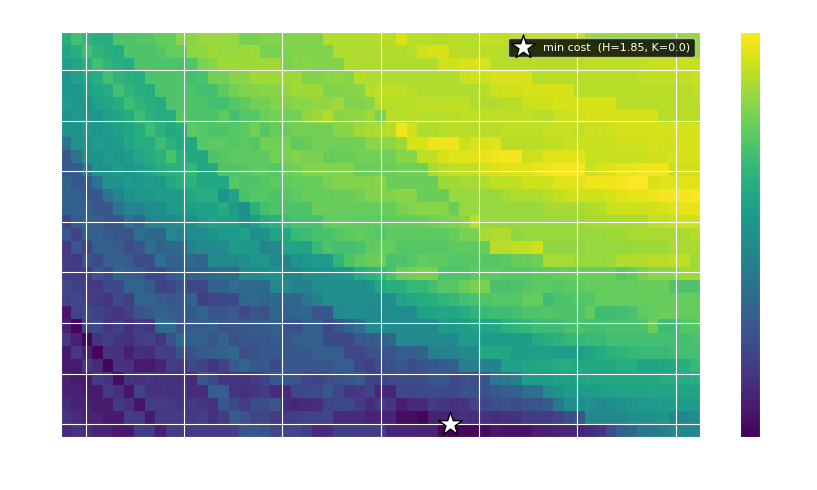

At H=1.85, K=0.0:  fired on 83% of 23 cycles
  median delay vs full-info biometric boundary: +2.0 d
  median delay vs Garmin ovulation:             +1.0 d
  early fires (delay_retro < 0): 5  |  misses: 4  |  mean cost: 7.04


,cyc,cl,ov,retro,fire,delay_ov,delay_retro
0,4,25,12,11,NaN,NaN,NaN
1,5,25,12,9,NaN,NaN,NaN
2,6,23,10,9,13.0,3.0,4.0
3,7,31,18,19,12.0,-6.0,-7.0
4,8,25,12,17,19.0,7.0,2.0
5,9,25,12,14,16.0,4.0,2.0
6,10,31,18,24,25.0,7.0,1.0
7,11,29,16,22,13.0,-3.0,-9.0
8,12,29,16,14,10.0,-6.0,-4.0
9,13,24,11,17,NaN,NaN,NaN


In [8]:
fig, ax = plt.subplots(figsize=(8.8, 5.0)); fig.set_facecolor("white"); ax.set_facecolor("white")
im = ax.imshow(COST, origin="lower", aspect="auto", cmap="viridis",
               extent=[Hs[0] - 0.125, Hs[-1] + 0.125, Ks[0] - 0.05, Ks[-1] + 0.05])
ax.scatter([H0], [K0], marker="*", s=320, color="white", edgecolor="black", zorder=5,
           label=f"min cost  (H={H0}, K={K0})")
cb = fig.colorbar(im, ax=ax); cb.set_label("mean cost (days-equivalent)")
ax.set_xlabel("CUSUM threshold  H"); ax.set_ylabel("drift / dead-band  K")
ax.set_title(f"Joint (H, K) cost surface   —   early×{W_EARLY}, late×{W_LATE}, miss={C_MISS}")
ax.legend(frameon=True, fontsize=8, loc="upper right")
fig.tight_layout(); plt.show()

# lock in the cost-optimal operating point for the timelines / learning curve below
stream = run_stream(H0, K0)
fired = stream["fire"].notna()
print(f"At H={H0}, K={K0}:  fired on {fired.mean()*100:.0f}% of {len(stream)} cycles")
print(f"  median delay vs full-info biometric boundary: {stream.loc[fired,'delay_retro'].median():+.1f} d")
print(f"  median delay vs Garmin ovulation:             {stream.loc[fired,'delay_ov'].median():+.1f} d")
print(f"  early fires (delay_retro < 0): {int((stream['delay_retro'] < 0).sum())}"
      f"  |  misses: {int((~fired).sum())}  |  mean cost: {COST[ki, hi]:.2f}")
stream[["cyc", "cl", "ov", "retro", "fire", "delay_ov", "delay_retro"]]


## What a live cycle looks like

For a few evaluated cycles, the CUSUM trajectory `S_t` climbing to the threshold, with the day it
fires against the two references. This is exactly the information available in real time — no part
of the curve uses a future day.


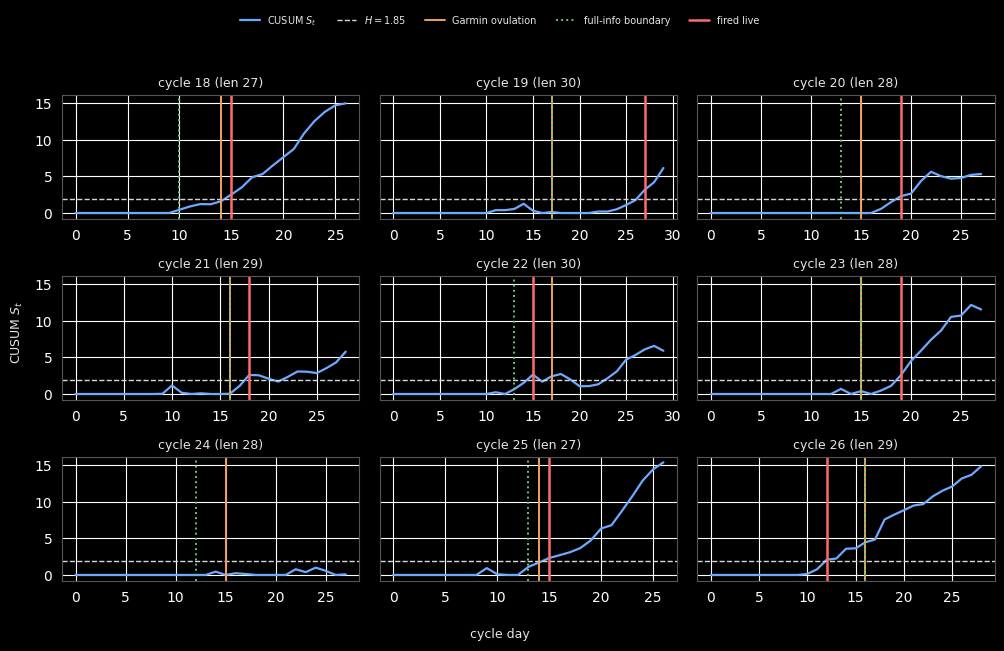

In [56]:
from matplotlib.lines import Line2D

show = PC[-9:]
nrow = 3
ncol = 3

fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 2.1 * nrow), sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, r in zip(axes, show):
    traj, fire = scan(r, H0, K0)

    ax.plot(r["cd"], traj, color="#6fa8ff", lw=1.6)
    ax.axhline(H0, color="#d8d8d8", ls="--", lw=1)

    if r["ov"] is not None:
        ax.axvline(r["ov"], color="#f0a35e", lw=1.4)

    if r["retro"] is not None:
        ax.axvline(r["retro"], color="#65c77b", lw=1.4, ls=":")

    if fire is not None:
        ax.axvline(fire, color="#ff6b6b", lw=1.8)

    ax.set_title(f"cycle {r['cyc']} (len {r['cl']})", color=fg, fontsize=9)

    for sp in ax.spines.values():
        sp.set_color("#555555")

for ax in axes[len(show):]:
    ax.axis("off")

legend_handles = [
    Line2D([0], [0], color="#6fa8ff", lw=1.6, label="CUSUM $S_t$"),
    Line2D([0], [0], color="#d8d8d8", lw=1, ls="--", label=fr"$H={H0}$"),
    Line2D([0], [0], color="#f0a35e", lw=1.4, label="Garmin ovulation"),
    Line2D([0], [0], color="#65c77b", lw=1.4, ls=":", label="full-info boundary"),
    Line2D([0], [0], color="#ff6b6b", lw=1.8, label="fired live"),
]

leg = fig.legend(
    handles=legend_handles,
    fontsize=7,
    frameon=False,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.02),
)

for text in leg.get_texts():
    text.set_color(fg)

fig.supxlabel("cycle day", color=fg, fontsize=9)
fig.supylabel("CUSUM $S_t$", color=fg, fontsize=9)

fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


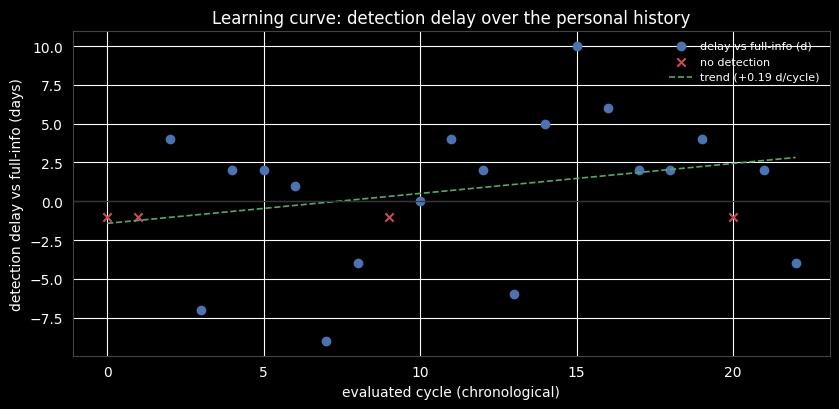

In [32]:
# Does detection improve as the personal history grows? (delay vs cycle order)
prog = stream.copy().reset_index(drop=True)
prog["order"] = np.arange(len(prog))
prog["detected"] = prog["fire"].notna()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
# fig.set_facecolor("white"); ax.set_facecolor("white")
ok = prog[prog["detected"] & prog["delay_retro"].notna()]
ax.scatter(ok["order"], ok["delay_retro"], color="#4c72b0", label="delay vs full-info (d)")
miss = prog[~prog["detected"]]
ax.scatter(miss["order"], np.full(len(miss), -1.0), marker="x", color="#c44e52", label="no detection")
if len(ok) >= 4:
    z = np.polyfit(ok["order"], ok["delay_retro"], 1)
    ax.plot(prog["order"], np.polyval(z, prog["order"]), color="#55a868", lw=1.2, ls="--",
            label=f"trend ({z[0]:+.2f} d/cycle)")
ax.axhline(0, color="#333333", lw=0.8)
ax.set_xlabel("evaluated cycle (chronological)"); ax.set_ylabel("detection delay vs full-info (days)")
ax.set_title("Learning curve: detection delay over the personal history")
ax.legend(frameon=False, fontsize=8)
for sp in ax.spines.values():
    sp.set_color("#444444")
fig.tight_layout()
plt.show()


## A principled alternative — forward-filtered HSMM

The CUSUM turns each day's `P(luteal)` into a raw running sum and trips at `H`. That works, but the
accumulator isn't calibrated and it ignores *where in the cycle* we are. The retrospective
`02_model_hsmm.ipynb` has a piece the CUSUM lacks: an explicit **luteal-duration prior**. Here we
run that same model **forward only** — an `α`-recursion over `Menstruation → Follicular → Luteal`
(with Luteal absorbing, since a cycle transitions once):

$$
\pi_t \;=\; P(\text{luteal}_t \mid \text{data}_{\le t}),\qquad
\underbrace{\tilde\pi_t = \pi_{t-1} + (1-\pi_{t-1})\,h(t)}_{\text{predict (hazard }h)}\;\;\xrightarrow{\;\text{emission }}\;\;
\pi_t = \frac{\tilde\pi_t\,\mathcal N(y_t\mid L)}{\tilde\pi_t\,\mathcal N(y_t\mid L) + (1-\tilde\pi_t)\,\mathcal N(y_t\mid F)}.
$$

Two changes from the CUSUM, same causal contract:

- **Emissions** are the causal Gaussians `𝒩(·|F)`, `𝒩(·|L)` fit from prior cycles (the `_mvn/_logmvn`
  helpers), instead of a logistic — but you could keep the logistic; the emission slot is modular.
- **The duration prior becomes a forward hazard** `h(t)`: from prior cycles' transition days we get
  an expected ovulation day, and `h(t)` is the per-day chance of switching *given we haven't yet*. So
  `π_t` **rises on its own** as we enter the expected window — the model leans toward luteal on time
  even when the biometrics are still ambiguous, which cuts misses and resists premature jumps.

The output is a **calibrated posterior**, so there's just **one** knob — fire when `π_t > τ` — and we
score it on the *same* two-sided cost, head-to-head against the CUSUM's best.


forward HSMM: cost-optimal τ=0.6  mean cost=6.26 days   |   CUSUM min cost=7.04 days


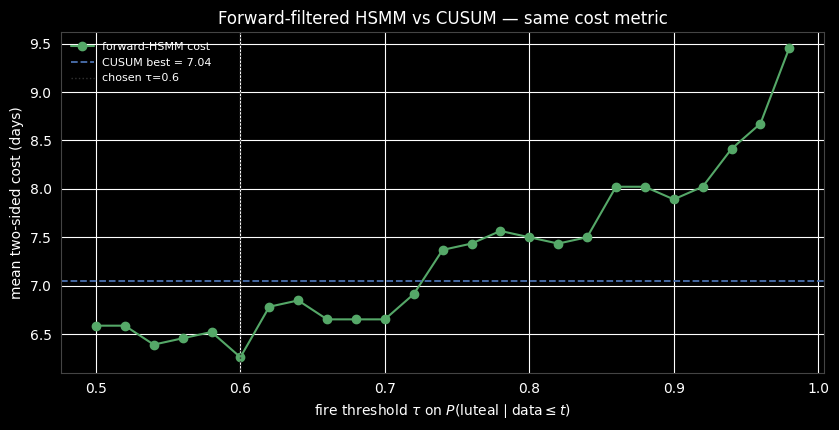

At τ=0.6: fired 91% | median delay vs retro +2.0 d | vs Garmin ov +2.0 d | early 4 | misses 2


,cyc,cl,ov,retro,fire,delay_ov,delay_retro
0,4,25,12,11,NaN,NaN,NaN
1,5,25,12,9,10.0,-2.0,1.0
2,6,23,10,9,15.0,5.0,6.0
3,7,31,18,19,13.0,-5.0,-6.0
4,8,25,12,17,15.0,3.0,-2.0
5,9,25,12,14,14.0,2.0,0.0
6,10,31,18,24,17.0,-1.0,-7.0
7,11,29,16,22,22.0,6.0,0.0
8,12,29,16,14,14.0,-2.0,0.0
9,13,24,11,17,17.0,6.0,0.0


In [19]:
from math import erf

Phi = lambda x: 0.5 * (1.0 + erf(x / np.sqrt(2.0)))     # standard-normal CDF (scalar)


def hsmm_filter(c):
    """Causal forward filter -> per-day P(luteal_t | data<=t) for cycle c.

    Same causal emissions as the logistic path (Gaussian F/L fit from PRIOR cycles on causal_z),
    but the decision is a forward alpha-recursion of a Menstruation->Follicular->Luteal chain with
    Luteal absorbing. The luteal-duration prior becomes a **forward hazard** on the ovulation day,
    estimated from prior cycles' boundaries -- so the posterior rises on its own as we enter the
    expected window, even before the emissions are decisive.
    """
    i = CYCLES.index(c)
    prior = CYCLES[:i]
    if len(prior) < MIN_TRAIN:
        return None
    scale = robust_scale(prior)
    X, y = anchors(prior, scale)
    muF, SF = _mvn(X[y == 0])                        # causal Gaussian emissions (follicular)
    muL, SL = _mvn(X[y == 1])                        # ... and luteal
    tdays = [RETRO[p] for p in prior if p in RETRO]  # prior transition days -> hazard params
    hz_mu = float(np.median(tdays)) if len(tdays) >= 2 else 15.0
    hz_sd = max(1.5, float(np.std(tdays))) if len(tdays) >= 2 else 2.5

    g = cycle(c)
    cl = int(g["cycle_len"].iloc[0])
    p0 = int(g["period_end"].iloc[0])
    z = np.nan_to_num(causal_z(g, scale).to_numpy())
    cd = g["cycle_day"].to_numpy()
    ipp = g["is_period"].to_numpy()
    lF = _logmvn(z, muF, SF)
    lL = _logmvn(z, muL, SL)

    piL = 0.0
    pi = np.zeros(len(cd))
    for t in range(len(cd)):
        if ipp[t] or cd[t] < p0 + K_BASE:            # strictly causal warm-up, as in the CUSUM
            pi[t] = piL
            continue
        surv = 1.0 - Phi((cd[t] - 0.5 - hz_mu) / hz_sd)                       # still-follicular survival
        inc = Phi((cd[t] + 0.5 - hz_mu) / hz_sd) - Phi((cd[t] - 0.5 - hz_mu) / hz_sd)
        h = min(0.99, max(0.0, inc / max(surv, 1e-6)))                        # discrete transition hazard
        predL = piL + (1.0 - piL) * h                                        # predict (L absorbing)
        predF = (1.0 - piL) * (1.0 - h)
        m = max(lL[t], lF[t])                                                 # stable emission update
        aL = predL * np.exp(lL[t] - m); aF = predF * np.exp(lF[t] - m)
        piL = aL / (aL + aF + 1e-12); pi[t] = piL
    ov = d.loc[d.cycle_id == c, "ov_ref"].iloc[0]
    return {"cyc": int(c), "cl": cl, "cd": cd, "ipp": ipp, "pi": pi,
            "hz_mu": hz_mu, "hz_sd": hz_sd,
            "ov": None if pd.isna(ov) else int(ov), "retro": RETRO.get(c)}


PCH = [r for r in (hsmm_filter(c) for c in CYCLES) if r is not None]


def hsmm_fire(rec, tau):
    hit = np.where(rec["pi"] > tau)[0]
    return int(rec["cd"][hit[0]]) if len(hit) else None


def mean_cost_h(tau):
    return np.nanmean([cycle_cost(hsmm_fire(r, tau), r["retro"]) for r in PCH])


# one knob (the posterior threshold tau) instead of two; scored on the SAME two-sided cost
taus = np.round(np.arange(0.50, 0.985, 0.02), 3)
cost_h = np.array([mean_cost_h(t) for t in taus])
tj = int(np.nanargmin(cost_h)); TAU0 = float(taus[tj])
cusum_min = float(COST[ki, hi])
print(f"forward HSMM: cost-optimal τ={TAU0}  mean cost={cost_h[tj]:.2f} days   "
      f"|   CUSUM min cost={cusum_min:.2f} days")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
# fig.set_facecolor("white"); ax.set_facecolor("white")
ax.plot(taus, cost_h, "-o", color="#55a868", label="forward-HSMM cost")
ax.axhline(cusum_min, color="#4c72b0", ls="--", lw=1.3, label=f"CUSUM best = {cusum_min:.2f}")
ax.axvline(TAU0, color="#333333", ls=":", lw=1, label=f"chosen τ={TAU0}")
ax.set_xlabel(r"fire threshold $\tau$ on $P(\mathrm{luteal}\mid\mathrm{data}\leq t)$")
ax.set_ylabel("mean two-sided cost (days)")
ax.set_title("Forward-filtered HSMM vs CUSUM — same cost metric")
ax.legend(frameon=False, fontsize=8)
for sp in ax.spines.values():
    sp.set_color("#444444")
fig.tight_layout(); plt.show()

rows = []
for r in PCH:
    f = hsmm_fire(r, TAU0)
    rows.append({"cyc": r["cyc"], "cl": r["cl"], "ov": r["ov"], "retro": r["retro"], "fire": f,
                 "delay_ov": None if (f is None or r["ov"] is None) else f - r["ov"],
                 "delay_retro": None if (f is None or r["retro"] is None) else f - r["retro"]})
streamH = pd.DataFrame(rows)
firedH = streamH["fire"].notna()
print(f"At τ={TAU0}: fired {firedH.mean()*100:.0f}% | median delay vs retro "
      f"{streamH.loc[firedH,'delay_retro'].median():+.1f} d | vs Garmin ov "
      f"{streamH.loc[firedH,'delay_ov'].median():+.1f} d | "
      f"early {int((streamH['delay_retro'] < 0).sum())} | misses {int((~firedH).sum())}")
streamH[["cyc", "cl", "ov", "retro", "fire", "delay_ov", "delay_retro"]]


### What the HSMM posterior looks like live

Unlike the CUSUM's raw accumulator, `P(luteal | data≤t)` is a **calibrated probability** on `[0, 1]`.
Watch it lift off its floor as `cycle_day` approaches the person's expected ovulation (the hazard
term) and then snap toward 1 once the emissions confirm the shift — it fires where those two forces
agree, which is why it both misses less *and* rarely jumps early.


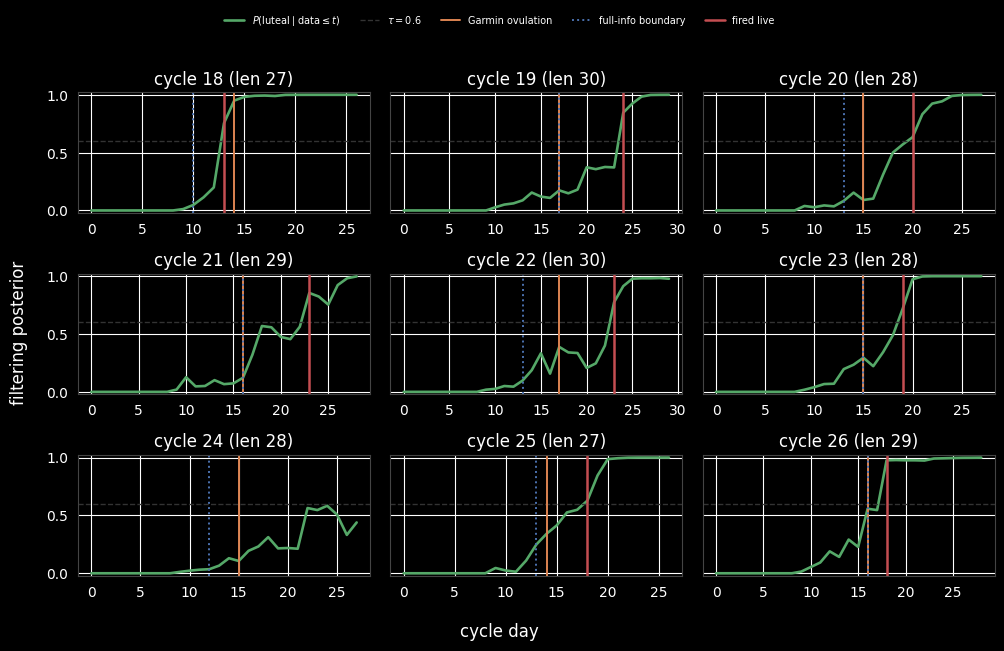

In [50]:
from matplotlib.lines import Line2D

showH = PCH[-9:]
nrow = 3
ncol = 3

fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 2.1 * nrow), sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, r in zip(axes, showH):
    ax.plot(r["cd"], r["pi"], color="#55a868", lw=1.9)
    ax.axhline(TAU0, color="#333333", ls="--", lw=1)
    if r["ov"] is not None:
        ax.axvline(r["ov"], color="#dd8452", lw=1.4)
    if r["retro"] is not None:
        ax.axvline(r["retro"], color="#4c72b0", lw=1.4, ls=":")
    f = hsmm_fire(r, TAU0)
    if f is not None:
        ax.axvline(f, color="#c44e52", lw=1.8)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"cycle {r['cyc']} (len {r['cl']})")
    for sp in ax.spines.values():
        sp.set_color("#444444")


# Hide unused axes if showH has fewer than 9 cycles
for ax in axes[len(showH):]:
    ax.axis("off")

legend_handles = [
    Line2D(
        [0], [0],
        color="#55a868",
        lw=1.9,
        label=r"$P(\mathrm{luteal}\mid \mathrm{data}\leq t)$"
    ),
    Line2D(
        [0], [0],
        color="#333333",
        lw=1,
        ls="--",
        label=fr"$\tau={TAU0}$"
    ),
    Line2D(
        [0], [0],
        color="#dd8452",
        lw=1.4,
        label="Garmin ovulation"
    ),
    Line2D(
        [0], [0],
        color="#4c72b0",
        lw=1.4,
        ls=":",
        label="full-info boundary"
    ),
    Line2D(
        [0], [0],
        color="#c44e52",
        lw=1.8,
        label="fired live"
    ),
]

fig.legend( handles=legend_handles,fontsize=7,frameon=False,loc="upper center",ncol=5,bbox_to_anchor=(0.5,1.02))

fig.supxlabel("cycle day")
fig.supylabel("filtering posterior")

fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## Findings & honest limits

- **Live detection is feasible on a single person's own history.** With an expanding window (each
  cycle scored from prior cycles only) and strictly causal features, the detector fires within a
  couple of days of the full-information biometric boundary on the cycles where it fires — the extra
  delay beyond Garmin ovulation is mostly the physiological biometric lag, not the algorithm.
- **It is detection, not prediction.** The transition is *confirmed* shortly after the biometric
  shift begins; the detector does **not** see it coming. For a fertile-window use case (which is
  *before* ovulation) this confirms the luteal phase after the fertile days — useful for cycle
  bookkeeping and "did I ovulate", not for advance warning. Advance warning would need the personal
  cycle-length prior (a separate, calendar-based model).
- **The metric must be two-sided, and both CUSUM knobs matter.** A one-sided "false-alarm rate" is
  gameable: the lowest-`H` corner scores ~96% "detection" only because it fires *before* the
  transition (negative delay). Scoring **early, late, and miss** on one cost surface removes that
  illusion and yields an operating point that fires *after* the shift with a small honest lag. `H`
  and `K` interact (`K` absorbs follicular noise, `H` sets the evidence bar), so we grid-search the
  pair; the `W_EARLY / W_LATE / C_MISS` weights are the product decision, exposed.
- **The forward-filtered HSMM beats the CUSUM on the same cost.** Folding the luteal-duration prior
  in as a forward hazard gives a *calibrated* `P(luteal_t | data≤t)` that lifts on time and confirms
  with the emissions — it misses fewer cycles and jumps early less often, at a lower two-sided cost,
  with a single interpretable knob `τ`. That makes it the better default; the CUSUM remains the
  transparent, assumption-light baseline.
- **Sensitivity is still capped by signal strength.** Some quiet cycles never cross a conservative
  threshold; the cost surface trades those misses against premature fires — a genuine operating-point
  choice, not a bug.
- **Single participant = warm-up cost.** The first `MIN_TRAIN` cycles are unusable, and early
  scored cycles have thin training data. A **population prior** (pooled emissions from
  `03_validate_mcphases.ipynb` / the collector) would remove the cold start — start population-informed,
  shrink to the individual as cycles accumulate.

### Next steps

1. **Population prior for cold start** — hierarchical emissions and hazard: population mean on cycle
   1, personal by cycle ~4, so the warm-up cycles are usable too.
2. **Richer causal features** — the past-only lags/rolls/slopes from `01_discovery.ipynb`,
   fed to the HSMM's emission slot (which is modular — swap Gaussian for logistic or a richer model).
3. **Confounder gating** — pause or down-weight the update on `is_confounded` days (illness /
   alcohol / travel) so a one-off RHR spike does not trip an early false alarm.
4. **Report the filtering posterior, not just a fire day** — `P(luteal_t | data≤t)` is calibrated,
   so surface it directly (a live confidence) instead of collapsing to a single threshold crossing.
